<a href="https://colab.research.google.com/github/Divya7803/hotel-reservation-demo/blob/main/heartdisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("/content/heart.csv")
print(df.to_string())

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
0     40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0
1     49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1
2     37   M           ATA        130          283          0         ST     98              N      0.0       Up             0
3     48   F           ASY        138          214          0     Normal    108              Y      1.5     Flat             1
4     54   M           NAP        150          195          0     Normal    122              N      0.0       Up             0
5     39   M           NAP        120          339          0     Normal    170              N      0.0       Up             0
6     45   F           ATA        130          237          0     Normal    170              N      0.0       U

In [2]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


In [8]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


In [9]:
df.rename(columns={'HeartDisease': 'target'}, inplace=True)

In [10]:
df['target'].value_counts()

,count
target,
1,508
0,410


<Axes: xlabel='Age', ylabel='Count'>

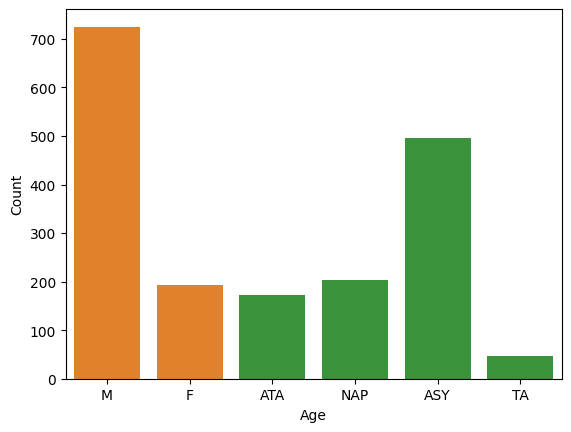

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], bins=20)
sns.countplot(x='Sex', data=df)
sns.countplot(x='ChestPainType', data=df)  # chest pain type

In [19]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df.columns:
    if df[col].dtype == 'object':
        df_encoded[col] = LabelEncoder().fit_transform(df[col])

<Axes: >

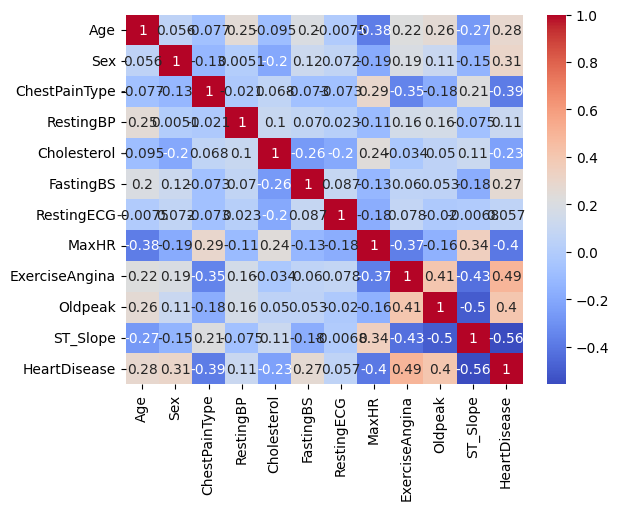

In [20]:
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

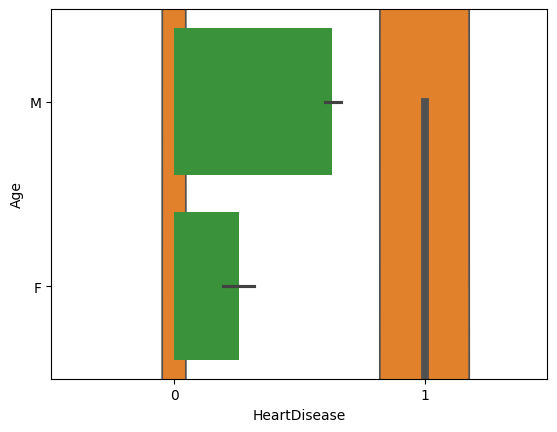

In [24]:
sns.boxplot(x='HeartDisease', y='Age', data=df)
sns.violinplot(x='HeartDisease', y='Cholesterol', data=df)
sns.barplot(x='HeartDisease', y='Sex', data=df)
plt.show()

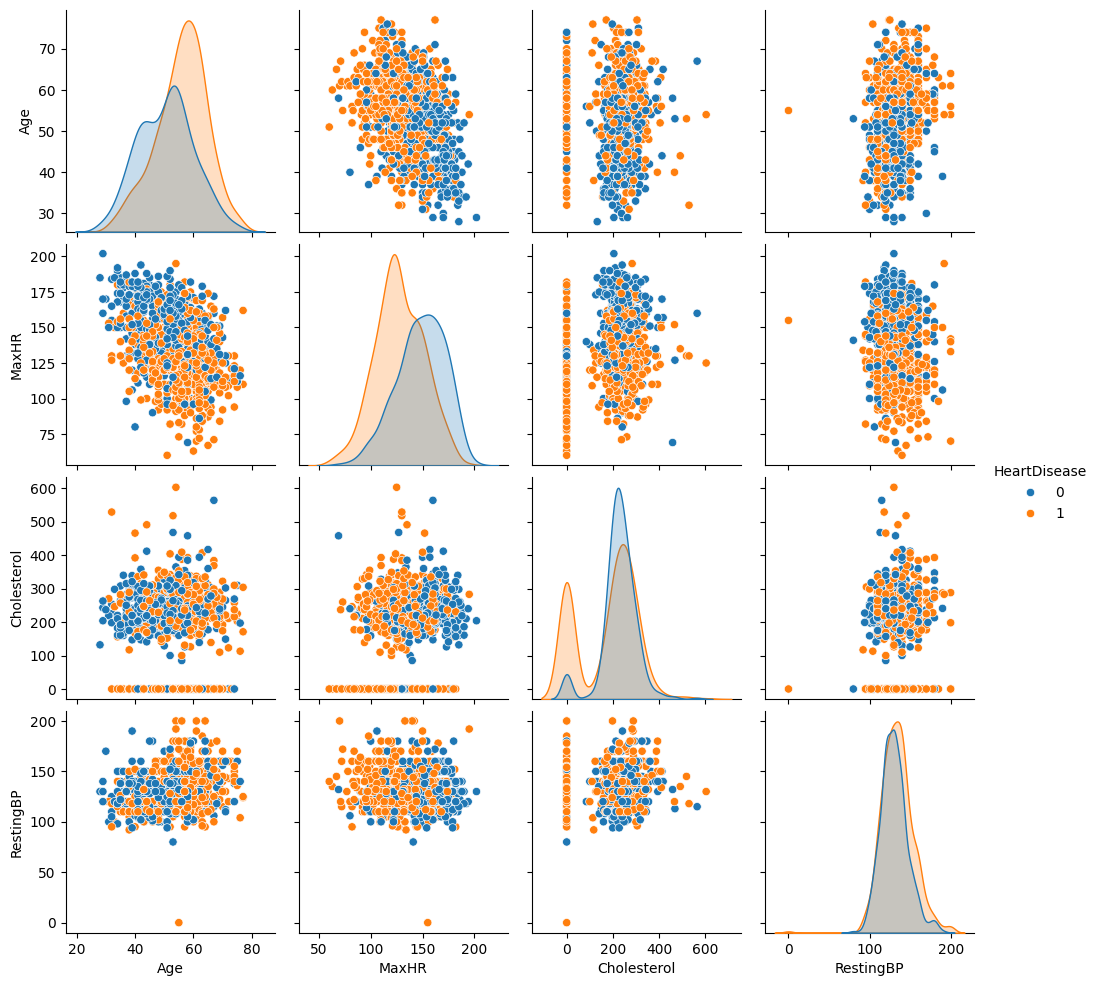

In [29]:
sns.pairplot(df[['Age', 'MaxHR', 'Cholesterol', 'RestingBP', 'HeartDisease']], hue='HeartDisease')

In [32]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode categorical columns
df_encoded = df.copy()

categorical_cols = df_encoded.select_dtypes(include='object').columns

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Step 2: Split X and y
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Step 3: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88        77
           1       0.92      0.91      0.91       107

    accuracy                           0.90       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



In [36]:
import joblib
joblib.dump(model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']